In [1]:
import logging
import math
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LOGGER = logging.getLogger(__name__)
if not LOGGER.handlers:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


@dataclass
class POMDPConfig:
    """Hidden-state benchmark DGP."""
    T: int = 3
    p: int = 5
    gamma: float = 0.99

    # Behavior policy
    sigma_A: float = 1.0

    # Observed-state transition
    rho_X: float = 0.65
    beta_A_to_X: float = 0.20
    sigma_X: float = 1.00
    hidden_drift: float = 0.85

    # Hidden-state transition
    hidden_intercept: float = 0.00
    hidden_persistence: float = 1.00
    hidden_x_effect: float = 0.80

    # Reward
    reward_intercept: float = 1.00
    reward_state: float = 1.00
    reward_action: float = 1.25
    reward_hidden: float = 0.75
    reward_action_hidden: float = 0.50
    sigma_R: float = 1.00
    reward_clip: float = 10.0


@dataclass
class LearnerConfig:
    """Training hyperparameters."""
    hidden_dim_q: int = 128
    depth_q: int = 2
    hidden_dim_h: int = 96
    depth_h: int = 2

    activation: str = "silu"

    lr_q: float = 5e-4
    lr_h: float = 5e-4
    weight_decay_q: float = 1e-4
    weight_decay_h: float = 1e-4
    batch_size_q: int = 512
    batch_size_h: int = 512
    epochs_q: int = 200
    epochs_h: int = 200

    val_fraction: float = 0.10
    patience: int = 20
    grad_clip: float = 5.0

    fd_step_scale: float = 0.05
    fd_step_min: float = 1e-3
    fd_step_max: float = 0.25


@dataclass
class MonteCarloConfig:
    """Monte Carlo experiment configuration."""
    N: int = 5000
    R: int = 100
    n_folds: int = 5

    oracle_eps: float = 0.05
    oracle_mc: int = 200_000

    se_method: str = "fold_cluster"  # or "iid"
    n_jobs: int = 1

    verbose: bool = True
    make_histograms: bool = True


@dataclass
class Standardizer:
    """Stage-specific standardization of S_t and A_t."""
    eps: float = 1e-8
    S_mean: Optional[np.ndarray] = None
    S_std: Optional[np.ndarray] = None
    A_mean: Optional[float] = None
    A_std: Optional[float] = None

    def fit(self, S: np.ndarray, A: np.ndarray) -> "Standardizer":
        S = np.asarray(S, dtype=np.float32)
        A = np.asarray(A, dtype=np.float32).reshape(-1, 1)
        self.S_mean = S.mean(axis=0, keepdims=True)
        self.S_std = np.maximum(S.std(axis=0, keepdims=True), self.eps)
        self.A_mean = float(A.mean())
        self.A_std = float(max(A.std(), self.eps))
        return self

    def transform_S(self, S: np.ndarray) -> np.ndarray:
        if self.S_mean is None or self.S_std is None:
            raise ValueError("Standardizer must be fit before calling transform_S.")
        S = np.asarray(S, dtype=np.float32)
        return (S - self.S_mean) / self.S_std

    def transform_A(self, A: np.ndarray) -> np.ndarray:
        if self.A_mean is None or self.A_std is None:
            raise ValueError("Standardizer must be fit before calling transform_A.")
        A = np.asarray(A, dtype=np.float32).reshape(-1, 1)
        return (A - self.A_mean) / self.A_std


@dataclass
class StageModel:
    model: nn.Module
    standardizer: Standardizer


@dataclass
class PanelData:
    """
    Panel data indexed by stage t = 1, ..., T.

    Hidden state U_t is stored only for simulation diagnostics; estimators never use it.
    """
    N: int
    T: int
    p: int
    gamma: float
    X: Dict[int, np.ndarray]
    U: Dict[int, np.ndarray]
    S: Dict[int, np.ndarray]
    A: Dict[int, np.ndarray]
    R: Dict[int, np.ndarray]
    Gamma: Dict[int, np.ndarray]
    pi_mean: Dict[int, np.ndarray]
    pi_var: Dict[int, np.ndarray]
    Y: np.ndarray


@dataclass
class CrossFitResult:
    theta_direct: float
    theta_asrw: float
    theta_asrw_oracle: float
    theta_srw: float
    contrib_direct: np.ndarray
    contrib_asrw: np.ndarray
    contrib_asrw_oracle: np.ndarray
    contrib_srw: np.ndarray
    fold_means: Dict[str, np.ndarray]
    fold_weights: np.ndarray


# =============================================================================
# Utilities
# =============================================================================

def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))


def choose_activation(name: str) -> nn.Module:
    if name.lower() == "relu":
        return nn.ReLU()
    if name.lower() == "gelu":
        return nn.GELU()
    return nn.SiLU()


def batch_predict(model: nn.Module, X: np.ndarray, batch_size: int = 8192) -> np.ndarray:
    model = model.to(DEVICE)
    model.eval()
    X = np.asarray(X, dtype=np.float32)
    out = np.empty(X.shape[0], dtype=np.float32)
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            end = min(X.shape[0], start + batch_size)
            xb = torch.as_tensor(X[start:end], dtype=torch.float32, device=DEVICE)
            out[start:end] = model(xb).squeeze(-1).detach().cpu().numpy()
    return out.astype(float)


def build_features(S_t: np.ndarray, A_t: np.ndarray, standardizer: Standardizer) -> np.ndarray:
    S_scaled = standardizer.transform_S(S_t)
    A_scaled = standardizer.transform_A(A_t)
    return np.hstack([A_scaled, S_scaled]).astype(np.float32)


def summarize_hidden_loadings(p: int) -> np.ndarray:
    """
    Loadings for the hidden regime drift.
    The first few coordinates are most informative; the remainder are weaker.
    """
    base = 1.0 / np.sqrt(np.arange(1, p + 1, dtype=np.float32))
    base = base / np.linalg.norm(base)
    return base.reshape(1, -1)


def subset_panel_data(panel: PanelData, idx: np.ndarray) -> PanelData:
    idx = np.asarray(idx, dtype=int)
    X = {t: panel.X[t][idx].copy() for t in range(1, panel.T + 1)}
    U = {t: panel.U[t][idx].copy() for t in range(1, panel.T + 1)}
    S = {t: panel.S[t][idx].copy() for t in range(1, panel.T + 1)}
    A = {t: panel.A[t][idx].copy() for t in range(1, panel.T + 1)}
    R = {t: panel.R[t][idx].copy() for t in range(1, panel.T + 1)}
    Gamma = {t: panel.Gamma[t][idx].copy() for t in range(1, panel.T + 1)}
    pi_mean = {t: panel.pi_mean[t][idx].copy() for t in range(1, panel.T + 1)}
    pi_var = {t: panel.pi_var[t][idx].copy() for t in range(1, panel.T + 1)}
    return PanelData(
        N=len(idx),
        T=panel.T,
        p=panel.p,
        gamma=panel.gamma,
        X=X,
        U=U,
        S=S,
        A=A,
        R=R,
        Gamma=Gamma,
        pi_mean=pi_mean,
        pi_var=pi_var,
        Y=panel.Y[idx].copy(),
    )


# =============================================================================
# DGP: simple POMDP benchmark
# =============================================================================

def generate_pomdp_benchmark(
    N: int,
    dgp: POMDPConfig,
    eps_shift: float = 0.0,
    seed: Optional[int] = None,
) -> PanelData:
    """
    Generate a simple POMDP benchmark with:
      - hidden regime U_t in {-1, +1}
      - observed X_t in R^p
      - Gaussian behavior policy with a location-shift path
      - rewards and observed dynamics affected by the hidden regime

    Actions depend only on the observed history, so sequential unconfoundedness
    with respect to S_t is preserved despite the hidden state.
    """
    rng = np.random.default_rng(seed)

    X: Dict[int, np.ndarray] = {}
    U: Dict[int, np.ndarray] = {}
    A: Dict[int, np.ndarray] = {}
    R: Dict[int, np.ndarray] = {}
    S: Dict[int, np.ndarray] = {}
    Gamma: Dict[int, np.ndarray] = {}
    pi_mean: Dict[int, np.ndarray] = {}
    pi_var: Dict[int, np.ndarray] = {}

    loadings = summarize_hidden_loadings(dgp.p)

    # Initial hidden state and observation
    U[1] = rng.choice(np.array([-1.0, 1.0], dtype=np.float32), size=(N, 1))
    X[1] = (
        0.75 * U[1] * loadings
        + 0.60 * rng.normal(size=(N, dgp.p)).astype(np.float32)
    ).astype(np.float32)

    zero_col = np.zeros((N, 1), dtype=np.float32)

    for t in range(1, dgp.T + 1):
        X_t = X[t]
        U_t = U[t]
        xbar_t = X_t.mean(axis=1, keepdims=True)

        A_prev = A[t - 1] if t > 1 else zero_col
        mu_t = 0.10 + 0.35 * xbar_t + 0.15 * A_prev
        A_t = mu_t + eps_shift + dgp.sigma_A * rng.normal(size=(N, 1)).astype(np.float32)

        reward_signal = (
            dgp.reward_intercept
            + dgp.reward_state * xbar_t
            + dgp.reward_action * A_t
            + dgp.reward_hidden * U_t
            + dgp.reward_action_hidden * A_t * U_t
        )
        R_t = reward_signal + dgp.sigma_R * rng.normal(size=(N, 1)).astype(np.float32)
        if dgp.reward_clip is not None and dgp.reward_clip > 0:
            R_t = np.clip(R_t, -dgp.reward_clip, dgp.reward_clip)

        A[t] = A_t.astype(np.float32)
        R[t] = R_t.astype(np.float32)
        pi_mean[t] = mu_t.astype(np.float32)
        pi_var[t] = np.full((N, 1), dgp.sigma_A ** 2, dtype=np.float32)

        if t < dgp.T:
            logits = (
                dgp.hidden_intercept
                + dgp.hidden_persistence * U_t
                + dgp.hidden_x_effect * xbar_t
            )
            prob_plus = sigmoid(logits)
            draw = rng.uniform(size=(N, 1)).astype(np.float32)
            U_next = np.where(draw < prob_plus, 1.0, -1.0).astype(np.float32)

            X_next = (
                dgp.rho_X * X_t
                + dgp.beta_A_to_X * A_t
                + dgp.hidden_drift * U_t * loadings
                + dgp.sigma_X * rng.normal(size=(N, dgp.p)).astype(np.float32)
            )
            U[t + 1] = U_next
            X[t + 1] = X_next.astype(np.float32)

    # Observed history S_t = (X_1, A_1, R_1, ..., X_t)
    for t in range(1, dgp.T + 1):
        pieces: List[np.ndarray] = []
        for j in range(1, t):
            pieces.extend([X[j], A[j], R[j]])
        pieces.append(X[t])
        S[t] = np.hstack(pieces).astype(np.float32)

    # Return-to-go Γ_t
    Gamma[dgp.T] = R[dgp.T].reshape(-1).astype(np.float32)
    for t in range(dgp.T - 1, 0, -1):
        Gamma[t] = (R[t].reshape(-1) + dgp.gamma * Gamma[t + 1]).astype(np.float32)

    return PanelData(
        N=N,
        T=dgp.T,
        p=dgp.p,
        gamma=dgp.gamma,
        X=X,
        U=U,
        S=S,
        A=A,
        R=R,
        Gamma=Gamma,
        pi_mean=pi_mean,
        pi_var=pi_var,
        Y=Gamma[1].copy(),
    )


# =============================================================================
# Oracle score H_t for the Gaussian mean-shift path
# =============================================================================

def oracle_score(panel: PanelData, var_floor: float = 1e-8) -> Dict[int, np.ndarray]:
    """
    For A_t | S_t ~ N(pi_mean_t(S_t), pi_var_t(S_t)),
    the location-shift score is
        H_t(S_t, A_t) = (A_t - pi_mean_t(S_t)) / pi_var_t(S_t).
    """
    H_star: Dict[int, np.ndarray] = {}
    for t in range(1, panel.T + 1):
        var_t = np.maximum(panel.pi_var[t].reshape(-1), var_floor)
        H_star[t] = ((panel.A[t].reshape(-1) - panel.pi_mean[t].reshape(-1)) / var_t).astype(float)
    return H_star


# =============================================================================
# Networks
# =============================================================================

class MLPRegressor(nn.Module):
    """
    Generic q-network for q_t(S_t, A_t).
    Input is [a_scaled, s_scaled].
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128, depth: int = 2, activation: str = "silu"):
        super().__init__()
        layers: List[nn.Module] = []
        d = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(choose_activation(activation))
            d = hidden_dim
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ScoreRegressor(nn.Module):
    """
    Generic score network for H_t(S_t, A_t).

    This is intentionally *not* restricted to an affine-in-action class.
    It is a flexible MLP over the full standardized feature vector
    [a_scaled, s_scaled], matching the paper's generic Auto-DML
    variational formulation over a chosen function class H_t.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 96, depth: int = 2, activation: str = "silu"):
        super().__init__()
        layers: List[nn.Module] = []
        d = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(choose_activation(activation))
            d = hidden_dim
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# =============================================================================
# Training
# =============================================================================

def _split_train_validation(
    X: np.ndarray,
    y: Optional[np.ndarray],
    val_fraction: float,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, Optional[np.ndarray], Optional[np.ndarray], Optional[np.ndarray]]:
    n = X.shape[0]
    if n <= 1 or val_fraction <= 0:
        return X, y, None, None

    n_val = max(1, int(round(val_fraction * n)))
    n_val = min(n_val, n - 1)
    perm = rng.permutation(n)
    val_idx = perm[:n_val]
    tr_idx = perm[n_val:]

    X_tr = X[tr_idx]
    y_tr = None if y is None else y[tr_idx]
    X_val = X[val_idx]
    y_val = None if y is None else y[val_idx]
    return X_tr, y_tr, X_val, y_val


def train_q_network(
    model: MLPRegressor,
    X: np.ndarray,
    y: np.ndarray,
    cfg: LearnerConfig,
    seed: int,
) -> MLPRegressor:
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)

    X_tr, y_tr, X_val, y_val = _split_train_validation(X, y, cfg.val_fraction, rng)

    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr_q, weight_decay=cfg.weight_decay_q)

    train_ds = TensorDataset(
        torch.as_tensor(X_tr, dtype=torch.float32),
        torch.as_tensor(y_tr, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size_q, shuffle=True)

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_val = float("inf")
    bad_epochs = 0

    for _ in range(cfg.epochs_q):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            loss.backward()
            if cfg.grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

        if X_val is None or y_val is None:
            continue

        model.eval()
        with torch.no_grad():
            xv = torch.as_tensor(X_val, dtype=torch.float32, device=DEVICE)
            yv = torch.as_tensor(y_val, dtype=torch.float32, device=DEVICE)
            val_loss = torch.mean((model(xv) - yv) ** 2).item()

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def _score_model_output_and_action_derivative(
    model: ScoreRegressor,
    xb: torch.Tensor,
    action_std: float,
    create_graph: bool,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Evaluate h(S_t, A_t) and ∂_a h(S_t, A_t) for a generic score network.

    The first column of xb is the standardized action
        a_scaled = (a - mean_A) / std_A.
    Therefore,
        ∂_a h = (∂ h / ∂ a_scaled) / std_A.
    """
    a_scaled = xb[:, :1].detach().clone().requires_grad_(True)
    s_scaled = xb[:, 1:]
    x_in = torch.cat([a_scaled, s_scaled], dim=1)

    h_val = model(x_in).squeeze(-1)
    dh_dascaled = torch.autograd.grad(
        outputs=h_val.sum(),
        inputs=a_scaled,
        create_graph=create_graph,
        retain_graph=create_graph,
        only_inputs=True,
    )[0].squeeze(-1)

    dh_da = dh_dascaled / float(action_std)
    return h_val, dh_da


def train_score_network(
    model: ScoreRegressor,
    X: np.ndarray,
    action_std: float,
    cfg: LearnerConfig,
    seed: int,
) -> ScoreRegressor:
    """
    Generic Auto-DML quadratic variational training for H_t:

        H_hat_t in argmin_h E_n[ h(S_t, A_t)^2 - 2 ∂_a h(S_t, A_t) ].

    This implementation is fully generic in (S_t, A_t): the score learner is
    a flexible neural network over the full input [a_scaled, s_scaled], and
    ∂_a h is computed by autograd rather than by imposing an affine-in-action
    structure.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)

    X_tr, _, X_val, _ = _split_train_validation(X, None, cfg.val_fraction, rng)

    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr_h, weight_decay=cfg.weight_decay_h)

    train_ds = TensorDataset(torch.as_tensor(X_tr, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size_h, shuffle=True)

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_val = float("inf")
    bad_epochs = 0

    if cfg.activation.lower() == "relu":
        LOGGER.warning(
            "ReLU is not ideal for derivative-based score learning. "
            "A smooth activation such as 'silu' or 'gelu' is recommended."
        )

    def objective(xb: torch.Tensor, create_graph: bool) -> torch.Tensor:
        h_val, dh_da = _score_model_output_and_action_derivative(
            model=model,
            xb=xb,
            action_std=action_std,
            create_graph=create_graph,
        )
        return torch.mean(h_val ** 2 - 2.0 * dh_da)

    for _ in range(cfg.epochs_h):
        model.train()
        for (xb,) in train_loader:
            xb = xb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = objective(xb, create_graph=True)
            loss.backward()
            if cfg.grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

        if X_val is None:
            continue

        model.eval()
        xv = torch.as_tensor(X_val, dtype=torch.float32, device=DEVICE)
        with torch.enable_grad():
            val_loss = objective(xv, create_graph=False).item()

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


# =============================================================================
# Stagewise nuisance estimation
# =============================================================================

def fit_q_models(panel: PanelData, cfg: LearnerConfig, seed: int) -> Dict[int, StageModel]:
    q_models: Dict[int, StageModel] = {}
    for t in range(1, panel.T + 1):
        std = Standardizer().fit(panel.S[t], panel.A[t])
        X_t = build_features(panel.S[t], panel.A[t], std)
        y_t = panel.Gamma[t]
        model = MLPRegressor(
            input_dim=X_t.shape[1],
            hidden_dim=cfg.hidden_dim_q,
            depth=cfg.depth_q,
            activation=cfg.activation,
        )
        model = train_q_network(model, X_t, y_t, cfg, seed=seed + 1000 * t)
        q_models[t] = StageModel(model=model, standardizer=std)
    return q_models


def fit_H_models(panel: PanelData, cfg: LearnerConfig, seed: int) -> Dict[int, StageModel]:
    H_models: Dict[int, StageModel] = {}
    for t in range(1, panel.T + 1):
        std = Standardizer().fit(panel.S[t], panel.A[t])
        X_t = build_features(panel.S[t], panel.A[t], std)
        model = ScoreRegressor(
            input_dim=X_t.shape[1],
            hidden_dim=cfg.hidden_dim_h,
            depth=cfg.depth_h,
            activation=cfg.activation,
        )
        model = train_score_network(model, X_t, action_std=std.A_std, cfg=cfg, seed=seed + 2000 * t)
        H_models[t] = StageModel(model=model, standardizer=std)
    return H_models


def predict_stage_models(stage_models: Dict[int, StageModel], panel: PanelData) -> Dict[int, np.ndarray]:
    out: Dict[int, np.ndarray] = {}
    for t, stage_model in stage_models.items():
        X_t = build_features(panel.S[t], panel.A[t], stage_model.standardizer)
        out[t] = batch_predict(stage_model.model, X_t)
    return out


# =============================================================================
# Direct estimator: finite differences only
# =============================================================================

def direct_stage_derivative_fd(
    q_model: StageModel,
    S_t: np.ndarray,
    A_t: np.ndarray,
    cfg: LearnerConfig,
) -> np.ndarray:
    """
    Central finite difference approximation to ∂_a q_t(S_t, A_t).

    A single stage-specific step size keeps the code simple and stable.
    """
    step = cfg.fd_step_scale * q_model.standardizer.A_std
    step = float(np.clip(step, cfg.fd_step_min, cfg.fd_step_max))

    A_plus = np.asarray(A_t, dtype=np.float32).reshape(-1, 1) + step
    A_minus = np.asarray(A_t, dtype=np.float32).reshape(-1, 1) - step

    X_plus = build_features(S_t, A_plus, q_model.standardizer)
    X_minus = build_features(S_t, A_minus, q_model.standardizer)

    q_plus = batch_predict(q_model.model, X_plus)
    q_minus = batch_predict(q_model.model, X_minus)
    return (q_plus - q_minus) / (2.0 * step)


# =============================================================================
# Cross-fitted estimation
# =============================================================================

def estimate_mpe_crossfit(
    panel: PanelData,
    learner: LearnerConfig,
    n_folds: int = 5,
    seed: int = 123,
) -> CrossFitResult:
    n = panel.N
    gamma = panel.gamma

    direct_contrib = np.zeros(n, dtype=float)
    asrw_contrib = np.zeros(n, dtype=float)
    asrw_oracle_contrib = np.zeros(n, dtype=float)
    srw_contrib = np.zeros(n, dtype=float)

    fold_means_direct: List[float] = []
    fold_means_asrw: List[float] = []
    fold_means_asrw_oracle: List[float] = []
    fold_means_srw: List[float] = []
    fold_weights: List[float] = []

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    all_idx = np.arange(n)

    for fold_id, (train_idx, score_idx) in enumerate(kf.split(all_idx), start=0):
        train_panel = subset_panel_data(panel, train_idx)
        score_panel = subset_panel_data(panel, score_idx)

        q_models = fit_q_models(train_panel, learner, seed=seed + 100 * fold_id)
        H_models = fit_H_models(train_panel, learner, seed=seed + 500 * fold_id)

        q_hat = predict_stage_models(q_models, score_panel)
        H_hat = predict_stage_models(H_models, score_panel)
        H_star = oracle_score(score_panel)

        direct_fold = np.zeros(len(score_idx), dtype=float)
        asrw_correction = np.zeros(len(score_idx), dtype=float)
        asrw_oracle_correction = np.zeros(len(score_idx), dtype=float)
        srw_fold = np.zeros(len(score_idx), dtype=float)

        for t in range(1, panel.T + 1):
            gamma_pow = gamma ** (t - 1)

            dq_da_hat = direct_stage_derivative_fd(
                q_model=q_models[t],
                S_t=score_panel.S[t],
                A_t=score_panel.A[t],
                cfg=learner,
            )
            residual = score_panel.Gamma[t] - q_hat[t]

            direct_fold += gamma_pow * dq_da_hat
            asrw_correction += gamma_pow * H_hat[t] * residual
            asrw_oracle_correction += gamma_pow * H_star[t] * residual
            srw_fold += gamma_pow * H_hat[t] * score_panel.Gamma[t]

        asrw_fold = direct_fold + asrw_correction
        asrw_oracle_fold = direct_fold + asrw_oracle_correction

        direct_contrib[score_idx] = direct_fold
        asrw_contrib[score_idx] = asrw_fold
        asrw_oracle_contrib[score_idx] = asrw_oracle_fold
        srw_contrib[score_idx] = srw_fold

        fold_means_direct.append(float(direct_fold.mean()))
        fold_means_asrw.append(float(asrw_fold.mean()))
        fold_means_asrw_oracle.append(float(asrw_oracle_fold.mean()))
        fold_means_srw.append(float(srw_fold.mean()))
        fold_weights.append(len(score_idx) / n)

    theta_direct = float(direct_contrib.mean())
    theta_asrw = float(asrw_contrib.mean())
    theta_asrw_oracle = float(asrw_oracle_contrib.mean())
    theta_srw = float(srw_contrib.mean())

    return CrossFitResult(
        theta_direct=theta_direct,
        theta_asrw=theta_asrw,
        theta_asrw_oracle=theta_asrw_oracle,
        theta_srw=theta_srw,
        contrib_direct=direct_contrib,
        contrib_asrw=asrw_contrib,
        contrib_asrw_oracle=asrw_oracle_contrib,
        contrib_srw=srw_contrib,
        fold_means={
            "Direct": np.asarray(fold_means_direct, dtype=float),
            "ASRW": np.asarray(fold_means_asrw, dtype=float),
            "ASRW (oracle score)": np.asarray(fold_means_asrw_oracle, dtype=float),
            "SRW": np.asarray(fold_means_srw, dtype=float),
        },
        fold_weights=np.asarray(fold_weights, dtype=float),
    )


# =============================================================================
# Oracle target Θ by finite differences along the policy path
# =============================================================================

def estimate_oracle_theta_fd(
    dgp: POMDPConfig,
    eps: float,
    N_mc: int,
    seed: int = 999,
    crn: bool = True,
) -> float:
    """
    Estimate the target
        Θ = d/dε E_ε[Σ_t γ^{t-1} R_t] |_{ε=0}
    by symmetric finite differences using the same random numbers when crn=True.
    """
    seed_plus = seed
    seed_minus = seed if crn else seed + 1

    data_plus = generate_pomdp_benchmark(N=N_mc, dgp=dgp, eps_shift=eps, seed=seed_plus)
    data_minus = generate_pomdp_benchmark(N=N_mc, dgp=dgp, eps_shift=-eps, seed=seed_minus)

    return float((data_plus.Y.mean() - data_minus.Y.mean()) / (2.0 * eps))


# =============================================================================
# Inference and metrics
# =============================================================================

def bias_and_rmse(estimates: np.ndarray, truth: float) -> Tuple[float, float]:
    estimates = np.asarray(estimates, dtype=float)
    bias = float(estimates.mean() - truth)
    rmse = float(np.sqrt(np.mean((estimates - truth) ** 2)))
    return bias, rmse


def se_iid(contrib: np.ndarray) -> float:
    contrib = np.asarray(contrib, dtype=float)
    return float(np.std(contrib, ddof=1) / np.sqrt(contrib.shape[0]))


def se_fold_cluster(theta_hat: float, fold_means: np.ndarray, fold_weights: np.ndarray) -> float:
    fold_means = np.asarray(fold_means, dtype=float)
    fold_weights = np.asarray(fold_weights, dtype=float)
    K = len(fold_means)
    if K <= 1:
        return float("nan")
    variance = (K / (K - 1)) * np.sum((fold_weights ** 2) * (fold_means - theta_hat) ** 2)
    return float(np.sqrt(max(variance, 0.0)))


def coverage_wald(estimates: np.ndarray, ses: np.ndarray, truth: float, z: float = 1.959963984540054) -> float:
    estimates = np.asarray(estimates, dtype=float)
    ses = np.asarray(ses, dtype=float)
    lower = estimates - z * ses
    upper = estimates + z * ses
    return float(np.mean((truth >= lower) & (truth <= upper)))


def choose_bins_fd(x: np.ndarray, min_bins: int = 12, max_bins: int = 40) -> int:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n <= 1:
        return min_bins
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr <= 1e-12:
        return int(np.clip(np.sqrt(n), min_bins, max_bins))
    bw = 2.0 * iqr / (n ** (1.0 / 3.0))
    if bw <= 1e-12:
        return int(np.clip(np.sqrt(n), min_bins, max_bins))
    return int(np.clip(math.ceil((x.max() - x.min()) / bw), min_bins, max_bins))


def plot_histograms(estimate_dict: Dict[str, np.ndarray], truth: float, trim: float = 0.02) -> None:
    names = list(estimate_dict.keys())
    all_values = np.concatenate([np.asarray(v, dtype=float) for v in estimate_dict.values()])
    all_values = all_values[np.isfinite(all_values)]
    if all_values.size == 0:
        return

    lo = np.quantile(all_values, trim)
    hi = np.quantile(all_values, 1.0 - trim)
    pad = 0.05 * (hi - lo + 1e-8)

    fig, axes = plt.subplots(1, len(names), figsize=(4.2 * len(names), 3.6), sharey=True, sharex=True)
    if len(names) == 1:
        axes = [axes]

    for ax, name in zip(axes, names):
        values = np.asarray(estimate_dict[name], dtype=float)
        bins = choose_bins_fd(values)
        ax.hist(values, bins=bins, density=True, alpha=0.9, edgecolor="white", linewidth=0.7)
        ax.axvline(truth, linestyle="--", linewidth=1.5, label="Truth")
        ax.axvline(np.mean(values), linewidth=1.5, label="Mean")
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Estimate")
        ax.set_xlim(lo - pad, hi + pad)
        ax.grid(alpha=0.25, linestyle=":")
    axes[0].set_ylabel("Density")
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# =============================================================================
# Monte Carlo wrappers
# =============================================================================

def run_single_replication(
    seed: int,
    dgp: POMDPConfig,
    learner: LearnerConfig,
    mc: MonteCarloConfig,
) -> Dict[str, float]:
    if mc.n_jobs != 1 and DEVICE.type == "cpu":
        torch.set_num_threads(1)
        try:
            torch.set_num_interop_threads(1)
        except RuntimeError:
            pass
    set_all_seeds(seed)

    panel = generate_pomdp_benchmark(N=mc.N, dgp=dgp, eps_shift=0.0, seed=seed)
    cf = estimate_mpe_crossfit(panel=panel, learner=learner, n_folds=mc.n_folds, seed=seed)

    if mc.se_method == "iid":
        se_direct = se_iid(cf.contrib_direct)
        se_asrw = se_iid(cf.contrib_asrw)
        se_asrw_oracle = se_iid(cf.contrib_asrw_oracle)
        se_srw = se_iid(cf.contrib_srw)
    elif mc.se_method == "fold_cluster":
        se_direct = se_fold_cluster(cf.theta_direct, cf.fold_means["Direct"], cf.fold_weights)
        se_asrw = se_fold_cluster(cf.theta_asrw, cf.fold_means["ASRW"], cf.fold_weights)
        se_asrw_oracle = se_fold_cluster(cf.theta_asrw_oracle, cf.fold_means["ASRW (oracle score)"], cf.fold_weights)
        se_srw = se_fold_cluster(cf.theta_srw, cf.fold_means["SRW"], cf.fold_weights)
    else:
        raise ValueError("mc.se_method must be 'iid' or 'fold_cluster'.")

    return {
        "theta_direct": cf.theta_direct,
        "theta_asrw": cf.theta_asrw,
        "theta_asrw_oracle": cf.theta_asrw_oracle,
        "theta_srw": cf.theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oracle": se_asrw_oracle,
        "se_srw": se_srw,
    }


def run_monte_carlo(
    dgp: POMDPConfig,
    learner: LearnerConfig,
    mc: MonteCarloConfig,
) -> Dict[str, Any]:
    t0 = time.time()

    if mc.verbose:
        LOGGER.info("Estimating oracle target Θ by finite differences.")
    theta_truth = estimate_oracle_theta_fd(
        dgp=dgp,
        eps=mc.oracle_eps,
        N_mc=mc.oracle_mc,
        seed=999,
        crn=True,
    )
    if mc.verbose:
        LOGGER.info("Oracle Θ ≈ %.4f", theta_truth)

    if mc.n_jobs == 1 or DEVICE.type == "cuda":
        replications = [
            run_single_replication(seed=r, dgp=dgp, learner=learner, mc=mc)
            for r in range(mc.R)
        ]
    else:
        replications = Parallel(n_jobs=mc.n_jobs, backend="loky")(
            delayed(run_single_replication)(seed=r, dgp=dgp, learner=learner, mc=mc)
            for r in range(mc.R)
        )

    theta_direct = np.array([r["theta_direct"] for r in replications], dtype=float)
    theta_asrw = np.array([r["theta_asrw"] for r in replications], dtype=float)
    theta_asrw_oracle = np.array([r["theta_asrw_oracle"] for r in replications], dtype=float)
    theta_srw = np.array([r["theta_srw"] for r in replications], dtype=float)

    se_direct = np.array([r["se_direct"] for r in replications], dtype=float)
    se_asrw = np.array([r["se_asrw"] for r in replications], dtype=float)
    se_asrw_oracle = np.array([r["se_asrw_oracle"] for r in replications], dtype=float)
    se_srw = np.array([r["se_srw"] for r in replications], dtype=float)

    summaries: List[Dict[str, float]] = []
    for name, est, se in [
        ("Direct", theta_direct, se_direct),
        ("ASRW", theta_asrw, se_asrw),
        ("ASRW (oracle)", theta_asrw_oracle, se_asrw_oracle),
        ("SRW", theta_srw, se_srw),
    ]:
        bias, rmse = bias_and_rmse(est, theta_truth)
        summaries.append({
            "Estimator": name,
            "Mean": float(np.mean(est)),
            "Bias": bias,
            "RMSE": rmse,
            "Coverage": coverage_wald(est, se, theta_truth),
        })

    elapsed = time.time() - t0

    if mc.verbose:
        print(f"\nMonte Carlo summary (N={mc.N}, R={mc.R}, T={dgp.T}, p={dgp.p})")
        print(f"Oracle Θ: {theta_truth:.4f}")
        header = f"{'Estimator':<18}{'Mean':>10}{'Bias':>10}{'RMSE':>10}{'Coverage':>10}"
        print(header)
        print("-" * len(header))
        for row in summaries:
            print(
                f"{row['Estimator']:<18}"
                f"{row['Mean']:>10.4f}"
                f"{row['Bias']:>10.4f}"
                f"{row['RMSE']:>10.4f}"
                f"{row['Coverage']:>10.3f}"
            )
        print(f"\nTime: {elapsed:.1f} seconds")

    if mc.make_histograms:
        plot_histograms(
            {
                "Direct": theta_direct,
                "ASRW": theta_asrw,
                "ASRW (oracle score)": theta_asrw_oracle,
                "SRW": theta_srw,
            },
            truth=theta_truth,
        )

    return {
        "theta_truth": theta_truth,
        "theta_direct": theta_direct,
        "theta_asrw": theta_asrw,
        "theta_asrw_oracle": theta_asrw_oracle,
        "theta_srw": theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oracle": se_asrw_oracle,
        "se_srw": se_srw,
        "summary_rows": summaries,
        "elapsed_seconds": elapsed,
    }


2026-04-04 18:41:53,951 | INFO | Estimating oracle target Θ by finite differences.
2026-04-04 18:41:54,017 | INFO | Oracle Θ ≈ 9.8339



Monte Carlo summary (N=5000, R=100, T=5, p=5)
Oracle Θ: 9.8339
Estimator               Mean      Bias      RMSE  Coverage
----------------------------------------------------------
Direct                9.6378   -0.1961    0.2549     0.260
ASRW                  9.7605   -0.0734    0.1705     0.900
ASRW (oracle)         9.7580   -0.0759    0.1705     0.840
SRW                   9.7534   -0.0805    0.2561     0.930

Time: 727.0 seconds


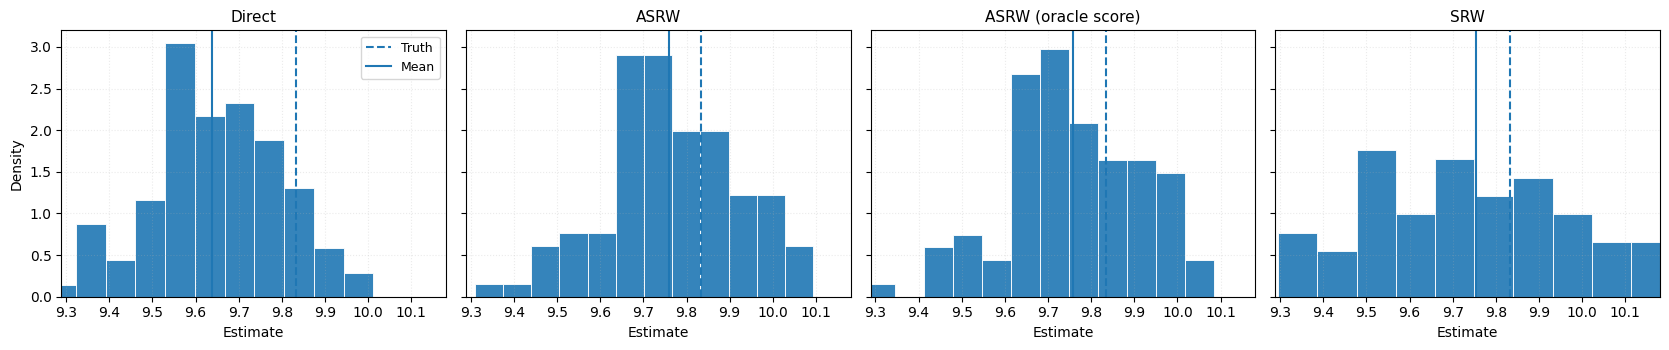

In [2]:
if __name__ == "__main__":
    dgp = POMDPConfig(T=5, p=5, gamma=0.99)
    learner = LearnerConfig(
        hidden_dim_q=64,
        depth_q=2,
        hidden_dim_h=64,
        depth_h=2,
        epochs_q=100,
        epochs_h=100,
    )
    mc = MonteCarloConfig(
        N=5000,
        R=100,
        n_folds=5,
        oracle_mc=50_000,
        n_jobs=-1,
        verbose=True,
        make_histograms=True,
    )
    run_monte_carlo(dgp=dgp, learner=learner, mc=mc)

2026-04-04 18:54:01,183 | INFO | Estimating oracle target Θ by finite differences.
2026-04-04 18:54:01,314 | INFO | Oracle Θ ≈ 9.7499



Monte Carlo summary (N=5000, R=100, T=5, p=10)
Oracle Θ: 9.7499
Estimator               Mean      Bias      RMSE  Coverage
----------------------------------------------------------
Direct                9.6234   -0.1265    0.1853     0.500
ASRW                  9.7885    0.0385    0.1165     0.950
ASRW (oracle)         9.7730    0.0230    0.1084     0.970
SRW                   9.7596    0.0096    0.1786     1.000

Time: 702.8 seconds


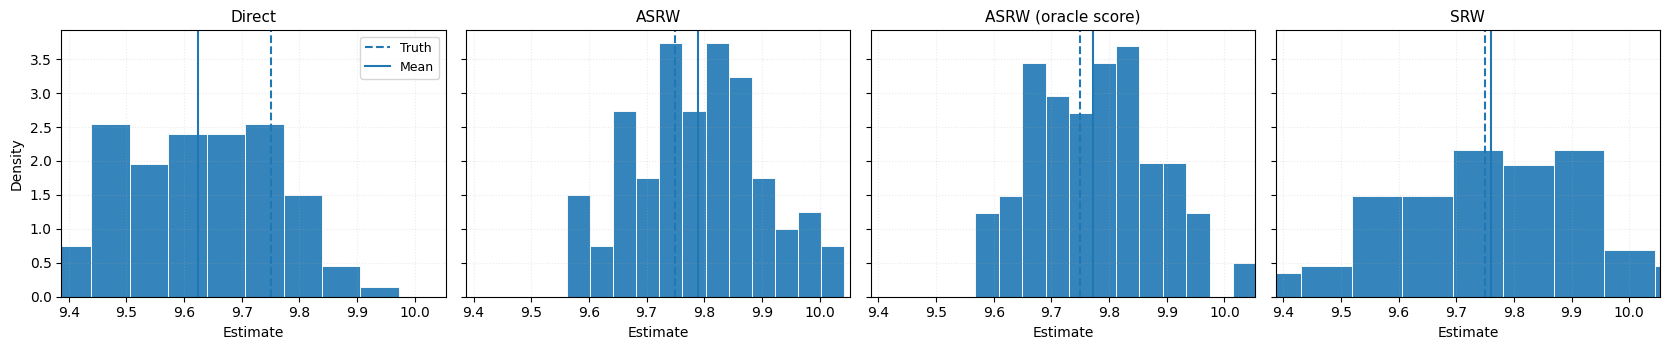

In [3]:
if __name__ == "__main__":
    dgp = POMDPConfig(T=5, p=10, gamma=0.99)
    learner = LearnerConfig(
        hidden_dim_q=64,
        depth_q=2,
        hidden_dim_h=64,
        depth_h=2,
        epochs_q=100,
        epochs_h=100,
    )
    mc = MonteCarloConfig(
        N=5000,
        R=100,
        n_folds=5,
        oracle_mc=50_000,
        n_jobs=-1,
        verbose=True,
        make_histograms=True,
    )
    run_monte_carlo(dgp=dgp, learner=learner, mc=mc)

2026-04-04 19:05:44,145 | INFO | Estimating oracle target Θ by finite differences.
2026-04-04 19:05:44,237 | INFO | Oracle Θ ≈ 9.8339



Monte Carlo summary (N=20000, R=100, T=5, p=5)
Oracle Θ: 9.8339
Estimator               Mean      Bias      RMSE  Coverage
----------------------------------------------------------
Direct                9.7209   -0.1130    0.1387     0.250
ASRW                  9.7654   -0.0685    0.1034     0.720
ASRW (oracle)         9.7636   -0.0702    0.1046     0.730
SRW                   9.8014   -0.0325    0.1241     0.930

Time: 2972.4 seconds


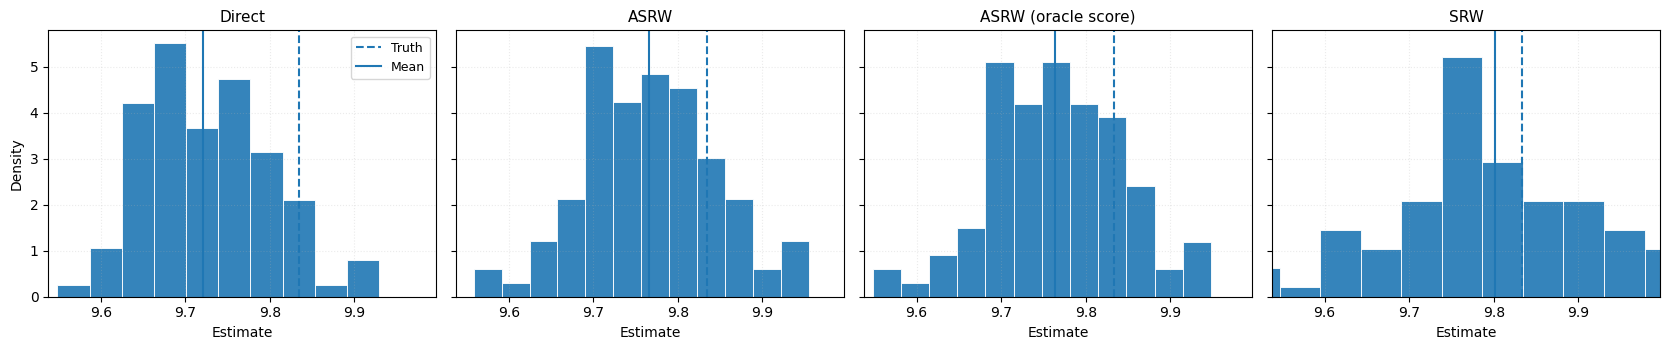

In [4]:
if __name__ == "__main__":
    dgp = POMDPConfig(T=5, p=5, gamma=0.99)
    learner = LearnerConfig(
        hidden_dim_q=64,
        depth_q=2,
        hidden_dim_h=64,
        depth_h=2,
        epochs_q=100,
        epochs_h=100,
    )
    mc = MonteCarloConfig(
        N=20000,
        R=100,
        n_folds=5,
        oracle_mc=50_000,
        n_jobs=-1,
        verbose=True,
        make_histograms=True,
    )
    run_monte_carlo(dgp=dgp, learner=learner, mc=mc)

2026-04-04 19:55:16,822 | INFO | Estimating oracle target Θ by finite differences.
2026-04-04 19:55:16,923 | INFO | Oracle Θ ≈ 9.7499
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Monte Carlo summary (N=20000, R=100, T=5, p=10)
Oracle Θ: 9.7499
Estimator               Mean      Bias      RMSE  Coverage
----------------------------------------------------------
Direct                9.7514    0.0015    0.0679     0.530
ASRW                  9.7861    0.0362    0.0740     0.830
ASRW (oracle)         9.7825    0.0325    0.0715     0.840
SRW                   9.8617    0.1117    0.1484     0.910

Time: 2124.5 seconds


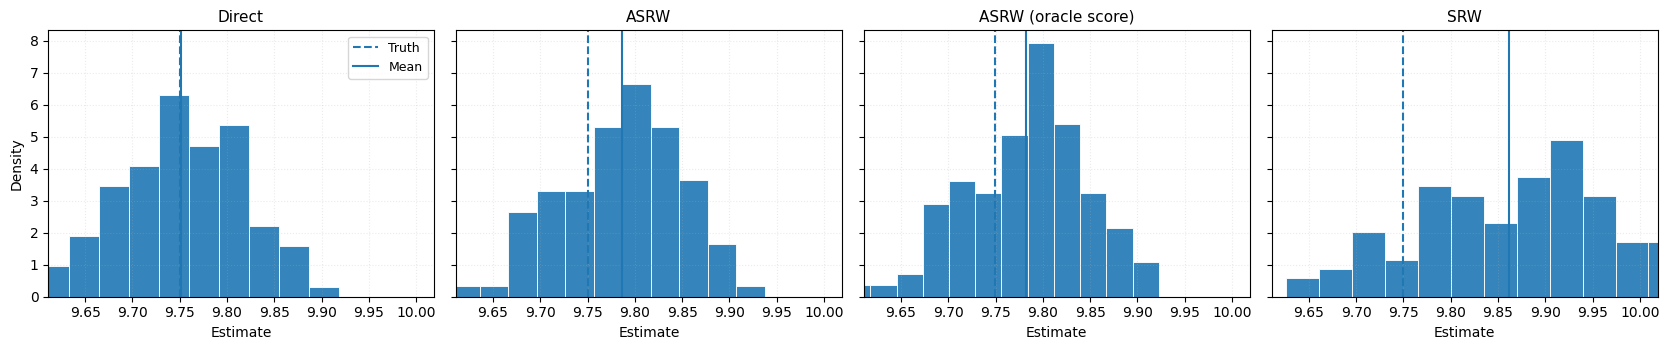

In [5]:
if __name__ == "__main__":
    dgp = POMDPConfig(T=5, p=10, gamma=0.99)
    learner = LearnerConfig(
        hidden_dim_q=64,
        depth_q=2,
        hidden_dim_h=64,
        depth_h=2,
        epochs_q=100,
        epochs_h=100,
    )
    mc = MonteCarloConfig(
        N=20000,
        R=100,
        n_folds=5,
        oracle_mc=50_000,
        n_jobs=-1,
        verbose=True,
        make_histograms=True,
    )
    run_monte_carlo(dgp=dgp, learner=learner, mc=mc)